## Entrenamiento inicial del modelo de ML

Se entrenan y comparan dos modelos de clasificación binaria (Regresión Logística y Random Forest)
sobre la tabla maestra, priorizando Recall como métrica de negocio (detectar la mayor cantidad
posible de usuarios en riesgo real de abandono), a lo largo del notebook se determino cual de los dos modelos elegir.

In [0]:
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, recall_score
)

import matplotlib.pyplot as plt

DB = "workspace.apuestas_db"
df = spark.table(f"{DB}.tabla_maestra_churn").toPandas()
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.isnull().sum()

Filas: 800, Columnas: 18


id_usuario                    0
saldo                         0
antiguedad_dias               0
dias_desde_ultima_apuesta     0
sin_apuestas_obs              0
dias_desde_ultimo_deposito    0
sin_depositos_obs             0
n_apuestas_total              0
n_apuestas_ult30d             0
n_apuestas_previas            0
tendencia_frecuencia          0
monto_promedio_apostado       0
monto_promedio_ult30d         0
sin_apuestas_resueltas        0
tasa_perdida                  0
n_depositos                   0
monto_total_depositado        0
churn                         0
dtype: int64

Como las columnas de nuestra tabla maestra no tienen nulos podemos seguir con el proceso de entrenamiento de nuestro modelo

Selección de features y separación X / y, x son todas las variables que usaremos para nuestro modelo (sin id usuario), mientras que y es el target (lo que queremos predecir), en este caso queremos predecir si el usuario abandonara la plataforma

In [0]:
features = [
    "antiguedad_dias",
    "dias_desde_ultima_apuesta",
    "sin_apuestas_obs",
    "dias_desde_ultimo_deposito",
    "sin_depositos_obs",
    "n_apuestas_total",
    "n_apuestas_ult30d",
    "n_apuestas_previas",
    "tendencia_frecuencia",
    "monto_promedio_apostado",
    "monto_promedio_ult30d",
    "tasa_perdida",
    "sin_apuestas_resueltas",
    "n_depositos",
    "monto_total_depositado"
]

X = df[features]
y = df["churn"]

Train/test split estratificado

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print("Proporción churn en train:", y_train.mean().round(3))
print("Proporción churn en test:", y_test.mean().round(3))

Train: 640 filas | Test: 160 filas
Proporción churn en train: 0.402
Proporción churn en test: 0.4


Escalado para regresion logistica, lo que hace esto es poner todas las variables en la misma escala (unificando sus magnitudes), asegurando que ninguna variable domine sobre otra solo por tener números más grandes.

In [0]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# fit calcula la media y la desviacion estandar sobre x_train

In [0]:
# Activa el rastreo automático de MLflow para Scikit-Learn
# Al ejecutarlo guarda automáticamente parámetros, métricas y el modelo entrenado
mlflow.sklearn.autolog()

Entrenamiento del Modelo de Logistic Regresion: se eligio regresión logística porque es el más sencillo para la clasificación binaria; predice la probabilidad de que un cliente se dé de baja en una escala del 0 al 1.

In [0]:
# Iniciando un experimento en MLflow para agrupar y guardar los resultados
with mlflow.start_run(run_name="logistic_regression_churn"):
    modelo_lr = LogisticRegression(
        class_weight="balanced", random_state=42, max_iter=1000
    )

    # Entrena el modelo
    modelo_lr.fit(X_train_scaled, y_train)

    # genera la probabilidad de que el usuario pertenezca a la clase 1 (churn)
    proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

    # Obtiene la predicción final binaria (0: Se queda, 1: Churn) 
    pred_lr = modelo_lr.predict(X_test_scaled)

    # Calcula las métricas de evaluación del set de prueba
    auc_lr = roc_auc_score(y_test, proba_lr)  
    recall_lr = recall_score(
        y_test, pred_lr
    )  # Mide qué porcentaje de los casos reales de churn se detectaron

    # Guardando en MLflow las métricas calculadas
    mlflow.log_metric("auc_test", auc_lr)
    mlflow.log_metric("recall_test", recall_lr)

print(f"AUC (Logistic Regression): {auc_lr:.4f}")
print(f"Recall (Logistic Regression): {recall_lr:.4f}")

2026/07/18 02:00:01 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
🔗 View Logged Model at: https://dbc-4de10b5c-ac73.cloud.databricks.com/ml/experiments/2103952991504615/models/m-339021dfb6d24b97b5efd3213c719f68?o=7474643814345624


AUC (Logistic Regression): 0.9896
Recall (Logistic Regression): 1.0000


Entrenando Random Forest

In [0]:
with mlflow.start_run(run_name="random_forest_churn"):
    modelo_rf = RandomForestClassifier(
        n_estimators=200, max_depth=6, class_weight="balanced",
        random_state=42
    )
    modelo_rf.fit(X_train, y_train)  # Random Forest usa datos SIN escalar

    proba_rf = modelo_rf.predict_proba(X_test)[:, 1]
    pred_rf = modelo_rf.predict(X_test)

    auc_rf = roc_auc_score(y_test, proba_rf)
    recall_rf = recall_score(y_test, pred_rf)

    mlflow.log_metric("auc_test", auc_rf)
    mlflow.log_metric("recall_test", recall_rf)

print(f"AUC (Random Forest): {auc_rf:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")

2026/07/18 02:00:55 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-4de10b5c-ac73.cloud.databricks.com/ml/experiments/2103952991504615/models/m-17715a8733d041bbbf9d928e4935ee52?o=7474643814345624


AUC (Random Forest): 0.9987
Recall (Random Forest): 1.0000


Comparación train vs test, verificamos que no exista el sobre entrenamiento con diferencias notorias entre los dos AUC de los modelos

In [0]:
print("=== Logistic Regression ===")
print(f"AUC train: {roc_auc_score(y_train, modelo_lr.predict_proba(X_train_scaled)[:,1]):.4f}")
print(f"AUC test:  {auc_lr:.4f}")

print("\n=== Random Forest ===")
print(f"AUC train: {roc_auc_score(y_train, modelo_rf.predict_proba(X_train)[:,1]):.4f}")
print(f"AUC test:  {auc_rf:.4f}")

=== Logistic Regression ===
AUC train: 0.9983
AUC test:  0.9896

=== Random Forest ===
AUC train: 1.0000
AUC test:  0.9987


 ambos modelos muestran métricas muy altas debido a la naturaleza
determinista de los datos sintéticos (el sesgo de perfil inyectado en la Fase 1 genera una
separación casi total entre clases). En un escenario de producción con datos reales,
se esperaría un AUC más bajo por el ruido natural del
comportamiento humano.

Importancia de variables - Random Forest, verificamos que el modelo no haya aprendido de una unica variable:

Importancia de variables (Random Forest):
                       feature  importancia
9      monto_promedio_apostado     0.186630
7           n_apuestas_previas     0.179237
5             n_apuestas_total     0.177221
8         tendencia_frecuencia     0.131587
10       monto_promedio_ult30d     0.121703
1    dias_desde_ultima_apuesta     0.079891
6            n_apuestas_ult30d     0.042288
13                 n_depositos     0.040548
14      monto_total_depositado     0.018096
11                tasa_perdida     0.017376
3   dias_desde_ultimo_deposito     0.002761
0              antiguedad_dias     0.001715
4            sin_depositos_obs     0.000938
12      sin_apuestas_resueltas     0.000010
2             sin_apuestas_obs     0.000000


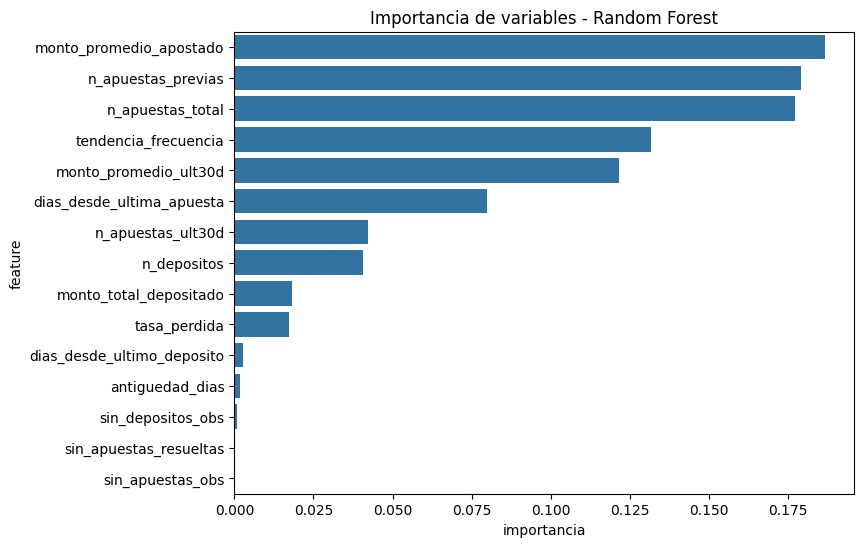

In [0]:
import seaborn as sns

importancias = pd.DataFrame({
    "feature": features,
    "importancia": modelo_rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("Importancia de variables (Random Forest):")
print(importancias)

plt.figure(figsize=(8,6))
sns.barplot(data=importancias, x="importancia", y="feature")
plt.title("Importancia de variables - Random Forest")
plt.show()

 ambos modelos muestran métricas muy altas debido a la naturaleza
determinista de los datos sintéticos (el sesgo de perfil inyectado en la Fase 1 genera una
separación casi total entre clases). En un escenario de producción con datos reales,
se esperaría un AUC más moderado (típicamente 0.70-0.85), dado el ruido natural del
comportamiento humano.

En nuestro proyecto, decidimos tomar el modelo de Random forest (AUC test = 0.9987,
recall = 1.00), por su mejor generalización (menor brecha train/test) y por proveer
`feature_importances_` de forma nativa, útil para las recomendaciones de negocio.


Celda final: generar probabilidad_fuga para TODOS los usuarios, agregamos la columa probabilidad_fuga para poder visualizarlo en databricks

In [0]:

# usamos todos los usuarios, mismas columnas que usamos en el entrenamiento
X_completo = df[features]

df["probabilidad_fuga"] = modelo_rf.predict_proba(X_completo)[:, 1]

# Guardamos como tabla Delta para conectar con Power BI 
spark_df_resultado = spark.createDataFrame(df[["id_usuario", "churn", "probabilidad_fuga"]])
spark_df_resultado.write.mode("overwrite").saveAsTable(f"{DB}.scoring_churn_usuarios")

print("Tabla scoring_churn_usuarios creada con probabilidad_fuga por usuario")
display(spark_df_resultado.orderBy(spark_df_resultado.probabilidad_fuga.desc()).limit(10))

Tabla scoring_churn_usuarios creada con probabilidad_fuga por usuario


id_usuario,churn,probabilidad_fuga
1619,1,1.0
1615,1,1.0
1609,1,1.0
1624,1,1.0
1606,1,1.0
1604,1,1.0
1602,1,1.0
1608,1,1.0
1622,1,1.0
1631,1,1.0
